### 1. Imports

In [1]:
import os
from pathlib import Path
import random
import time # Added for timing
import pandas as pd
import numpy as np # Added for stats
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import timm

# Try importing thop for FLOPs calculation
try:
    from thop import profile
except ImportError:
    print("Please install thop: pip install thop")
    profile = None

# Plotting and scoring
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

### 2. Globals and hyperparameters

In [2]:
DATA_DIR = Path('data/images')
CSV_PATH = DATA_DIR / '0_data.csv'
IMG_SIZE = 256
BATCH_SIZE = 16
NUM_WORKERS = 4
EPOCHS = 10
LR = 3e-4
VAL_SPLIT = 0.2
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(DEVICE)

cuda


### 3. Utils

In [3]:
random.seed(SEED)
torch.manual_seed(SEED)

def read_metadata(csv_path: Path):
    df = pd.read_csv(csv_path)
    return list(df.itertuples(index=False, name=None))  # (label, filename)

### 4. Data

In [4]:
class FeedingDataset(Dataset):
    def __init__(self, meta, img_dir, train=True):
        self.samples = meta
        self.img_dir = img_dir
        aug = [T.RandomResizedCrop(IMG_SIZE, scale=(0.8,1.0)), T.RandomHorizontalFlip(),]
        self.transform = T.Compose([*(aug if train else [T.Resize((IMG_SIZE, IMG_SIZE))]), T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        label, fname = self.samples[idx]
        img = Image.open(self.img_dir / fname).convert('RGB')
        img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

meta = read_metadata(CSV_PATH)
val_len = int(len(meta)*VAL_SPLIT)
train_len = len(meta)-val_len
train_meta, val_meta = random_split(meta, [train_len, val_len])
train_ds = FeedingDataset(train_meta, DATA_DIR, train=True)
val_ds = FeedingDataset(val_meta, DATA_DIR, train=False)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)

### 5. Network

In [5]:
model = timm.create_model('mobilevit_s', pretrained=True, num_classes=2)
model.to(DEVICE)

ByobNet(
  (stem): ConvNormAct(
    (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
  )
  (stages): Sequential(
    (0): Sequential(
      (0): BottleneckBlock(
        (conv1_1x1): ConvNormAct(
          (conv): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
        )
        (conv2_kxk): ConvNormAct(
          (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
          (bn): BatchNormAct2d(
            64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
   

### 6. Training

In [6]:
a_criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

for epoch in range(1, EPOCHS+1):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in train_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = a_criterion(logits, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()*y.size(0)
        preds = logits.argmax(1)
        correct += (preds==y).sum().item()
        total += y.size(0)
    train_acc = correct/total*100
    train_loss = loss_sum/total

    model.eval()
    with torch.no_grad():
        total, correct, loss_sum = 0, 0, 0.0
        for x, y in val_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = a_criterion(logits, y)
            loss_sum += loss.item()*y.size(0)
            preds = logits.argmax(1)
            correct += (preds==y).sum().item()
            total += y.size(0)
    val_acc = correct/total*100
    val_loss = loss_sum/total
    print(f'Epoch {epoch}/{EPOCHS} | Train L {train_loss:.3f} A {train_acc:.1f}% | Val L {val_loss:.3f} A {val_acc:.1f}%')

Epoch 1/10 | Train L 0.297 A 90.0% | Val L 0.175 A 94.4%
Epoch 2/10 | Train L 0.136 A 95.1% | Val L 0.202 A 94.1%
Epoch 3/10 | Train L 0.130 A 94.9% | Val L 0.117 A 95.6%
Epoch 4/10 | Train L 0.091 A 96.9% | Val L 0.144 A 93.3%
Epoch 5/10 | Train L 0.093 A 95.9% | Val L 0.198 A 90.0%
Epoch 6/10 | Train L 0.079 A 97.7% | Val L 0.128 A 94.4%
Epoch 7/10 | Train L 0.066 A 97.6% | Val L 0.164 A 94.4%
Epoch 8/10 | Train L 0.062 A 97.5% | Val L 0.143 A 94.1%
Epoch 9/10 | Train L 0.050 A 98.2% | Val L 0.281 A 90.0%
Epoch 10/10 | Train L 0.038 A 98.6% | Val L 0.384 A 90.4%


### 7. Evaluation and plots

--- Performance Metrics (Standard: 256x256) ---
Accuracy   : 0.9037
Precision  : 0.9839
Recall     : 0.8356
F1         : 0.9037
Specificity: 0.9839
FPR        : 0.0161
------------------------------
--- Hardware & Efficiency Metrics ---
Parameters             : 4,938,914
Disk Space (Weights)   : 19.01 MB
Throughput (256x256)   : 46.81 img/s

--- High-Resolution Benchmark (1038x1559) ---
FLOPs (High Res)       : 91.30 G
Measuring High-Res latency... Done.
Latency (1038x1559) : 173.03 ms ± 55.80 ms
Est. Throughput        : 5.78 img/s


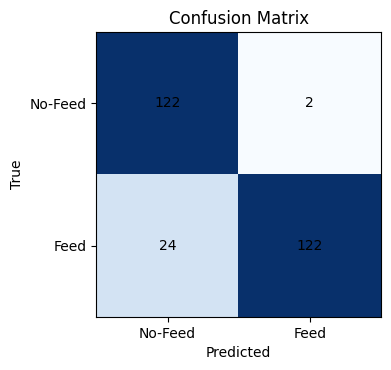

In [7]:
def report(loader, model, img_size=256):
    model.eval()
    
    print(f"--- Performance Metrics (Standard: {img_size}x{img_size}) ---")
    y_true, y_pred = [], []
    
    # 1. Standard Throughput (Batch Processing at 256x256)
    start_time_total = time.time()
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            preds = model(x).argmax(1)
            y_true.extend(y.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())
            
    total_time_set = time.time() - start_time_total

    # Calculate Standard Scores
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    acc = (tp + tn) / (tp + tn + fp + fn)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) else 0
    fpr = fp / (fp + tn) if (fp + tn) else 0

    print(f'Accuracy   : {acc:.4f}')
    print(f'Precision  : {prec:.4f}')
    print(f'Recall     : {rec:.4f}')
    print(f'F1         : {f1:.4f}')
    print(f'Specificity: {spec:.4f}')
    print(f'FPR        : {fpr:.4f}')
    print("-" * 30)

    print("--- Hardware & Efficiency Metrics ---")
    
    # 2. Parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Parameters             : {total_params:,}")

    # 3. Disk Space (Weights)
    temp_path = "temp_weights.pth"
    torch.save(model.state_dict(), temp_path)
    size_mb = os.path.getsize(temp_path) / (1024 * 1024)
    os.remove(temp_path)
    print(f"Disk Space (Weights)   : {size_mb:.2f} MB")

    # 4. Standard Latency (256x256)
    print(f"Throughput (256x256)   : {len(loader.dataset) / total_time_set:.2f} img/s")
    
    # 5. HIGH RESOLUTION BENCHMARK (1039x1591)
    # We create a dummy tensor of the exact shape you requested to test pure model speed
    # Note: We simulate a single image (Batch Size = 1)
    target_h, target_w = 1038, 1559
    print(f"\n--- High-Resolution Benchmark ({target_h}x{target_w}) ---")
    
    try:
        # Create a dummy image of the specific size
        # Shape: [Batch_Size, Channels, Height, Width]
        high_res_input = torch.randn(1, 3, target_h, target_w).to(DEVICE)
        
        # Calculate FLOPs for this large image
        if profile:
            macs_hr, _ = profile(model, inputs=(high_res_input, ), verbose=False)
            print(f"FLOPs (High Res)       : {macs_hr * 2 / 1e9:.2f} G")
        else:
            print("FLOPs                  : (thop library not installed)")

        # Measure Latency
        print("Measuring High-Res latency...", end="")
        hr_latencies = []
        
        with torch.no_grad():
            # Warmup (critical for large tensors to settle memory)
            for _ in range(3): 
                model(high_res_input)
            
            # Run 10 timing loops
            for _ in range(10):
                t0 = time.time()
                model(high_res_input)
                t1 = time.time()
                hr_latencies.append((t1 - t0) * 1000) # ms
        
        avg_hr_lat = np.mean(hr_latencies)
        std_hr_lat = np.std(hr_latencies)
        print(" Done.")
        print(f"Latency ({target_h}x{target_w}) : {avg_hr_lat:.2f} ms ± {std_hr_lat:.2f} ms")
        print(f"Est. Throughput        : {1000/avg_hr_lat:.2f} img/s")
        
    except RuntimeError as e:
        print(f"\nError: Could not run inference on {target_h}x{target_w}.")
        print(f"This is likely an Out-Of-Memory (OOM) error if the GPU is too small.")
        print(f"Details: {e}")

    # Plot Confusion Matrix
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, cmap='Blues')
    plt.xticks([0, 1], ['No-Feed', 'Feed'])
    plt.yticks([0, 1], ['No-Feed', 'Feed'])
    plt.title('Confusion Matrix')
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# Run the report
report(val_dl, model, IMG_SIZE)